## MCMC with BlackJAX

In [4]:
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platforms", "cuda")
_ = jax.devices("cuda")

import os
import sys
import tqdm
import corner
import numpy as np
import matplotlib.pyplot as plt
sys.path.append("../../src_jax")
from starspot import LightcurveModel
from mcmc import BlackJAXSampler
from gp_solver import GPSolver

np.random.seed(64)

results_dir = "results/"
if not os.path.exists(results_dir):
    os.makedirs(results_dir)

Generated synthetic lightcurve with 400 observations.


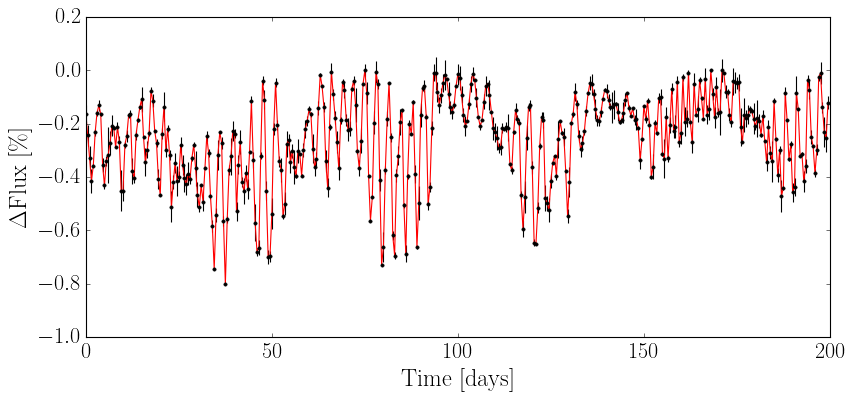

In [7]:
tsim = 200
tsamp = 0.5
nspot_per_day = 0.25
nspot = int(tsim * nspot_per_day)

# True parameters — use nspot_rate (spots/day) for correct kernel amplitude
# nspot is passed separately to LightcurveModel (total count for the simulation)
theta_full = dict(peq=3.0, kappa=0.3, inc=np.pi/3, nspot_rate=nspot_per_day,
                  lspot=12.0, tau=6.0, alpha_max=0.05, fspot=0.)

lc = LightcurveModel(peq=theta_full['peq'], kappa=theta_full['kappa'],
                     inc=theta_full['inc'], nspot=nspot,
                     lspot=theta_full['lspot'], tau=theta_full['tau'],
                     alpha_max=theta_full['alpha_max'], fspot=theta_full['fspot'],
                     tsim=tsim, tsamp=tsamp, lat=[-np.pi/2, np.pi/2], long=[0, 2*np.pi])
tobs = lc.t
flux = lc.flux
flux_err = np.abs(np.random.normal(0, 0.2*np.std(lc.flux), lc.flux.shape))

print(f"Generated synthetic lightcurve with {len(tobs)} observations.")
plt.figure(figsize=[12,5])
plt.errorbar(tobs, flux*100 - 100, yerr=flux_err*100, fmt=".k", capsize=0)
plt.plot(tobs, lc.flux*100 - 100, "r-")
plt.xlabel("Time [days]", fontsize=22)
plt.ylabel(r"$\Delta$Flux [\%]", fontsize=22)
plt.savefig(os.path.join(results_dir, "synthetic_lightcurve.png"), dpi=300)
plt.show()

### Initialize the GP and parameter bounds

In [8]:
bounds = {
    "peq":      (1.0, 5.0),
    "kappa":    (-1.0, 1.0),
    "inc":      (0.0, np.pi/2),
    "lspot":    (0.1, 20.0),
    "tau":      (0.1, 20.0),
    "sigma_k":  (1e-5, 0.1),   
}

gp = GPSolver(tobs, flux, flux_err, theta_full, bounds=bounds, matrix_solver="cholesky_banded")
theta_true = gp.get_theta()
print(f"True parameters: {theta_true}\n")

Banded Cholesky: bandwidth=120, N=400, sparsity=69.8%
True parameters: {'peq': 3.0, 'kappa': 0.3, 'inc': 1.0471975511965976, 'lspot': 12.0, 'tau': 6.0, 'sigma_k': 0.0012500000000000002}



### Run MCMC with BlackJAX

```{note}                                                                                              
You can set `theta_init` to the MAP solution (see [GP optimization notebook](gp_solver_quickstart.ipynb)).  

In [ ]:
sampler = BlackJAXSampler(gp)

# Initial run: warmup + first batch of samples
n_batches = 10
batch_size = 200
checkpoint_file = os.path.join(results_dir, "mcmc_checkpoint.npz")

samples, info = sampler.run_nuts(
      n_samples=batch_size,
      n_warmup=500,
      theta_init=None,   
      mass_matrix_method="hessian_map",
      progress_bar=False,
      checkpoint_file=checkpoint_file,
  )
sampler.save_checkpoint()  # appends samples to disk, clears memory

# Resume in batches — constant memory usage regardless of total samples
for _ in range(n_batches - 1):
    samples, info = sampler.resume_nuts(n_samples=batch_size)
    sampler.save_checkpoint()  # appends & clears